<a href="https://colab.research.google.com/github/true-cpu/2001230346_HoangTuanKiet_ThucHanhDeepLearning/blob/main/Buoi3_AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Nạp thư viện (Import Libraries)

Đầu tiên, chúng ta cần nạp các thư viện cần thiết cho việc xây dựng và huấn luyện mô hình Autoencoder, xử lý ảnh và hiển thị kết quả.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [ ]:
import os
import zipfile
import tensorflow as tf

ZIP_PATH = '/content/archive (1).zip'
EXTRACT_DIR = '/content/dataset_manual'

# 1. Giải nén (nếu chưa giải nén)
if not os.path.exists(EXTRACT_DIR):
    if os.path.exists(ZIP_PATH):
        try:
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print(f"Đã giải nén thành công vào {EXTRACT_DIR}")
        except zipfile.BadZipFile:
            print("Lỗi file zip.")
    else:
        print("Không tìm thấy file zip để giải nén.")

# 2. Tự động xác định đường dẫn tập train và valid
# Tìm thư mục chứa 'train' và 'valid' bên trong EXTRACT_DIR
train_path = None
valid_path = None

for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'train' in dirs and 'valid' in dirs:
        train_path = os.path.join(root, 'train')
        valid_path = os.path.join(root, 'valid')
        break

# Hàm thu thập tất cả ảnh từ một thư mục gốc
def get_all_images(folder):
    paths = []
    for r, d, f in os.walk(folder):
        for file in f:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(r, file))
    return paths

# 3. Nạp Dataset
IMG_WIDTH, IMG_HEIGHT, BATCH_SIZE = 128, 128, 32

def load_and_preprocess_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_WIDTH, IMG_HEIGHT])
    image = image / 255.0
    return image, image

if train_path and valid_path:
    train_files = get_all_images(train_path)
    val_files = get_all_images(valid_path)

    # Giới hạn số lượng ảnh nếu cần (ví dụ 2000 mỗi tập để chạy nhanh)
    train_ds = tf.data.Dataset.from_tensor_slices(train_files[:2000]).map(load_and_preprocess_image).cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices(val_files[:500]).map(load_and_preprocess_image).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    print(f"Đã nạp thành công: {len(train_files)} ảnh train, {len(val_files)} ảnh valid từ cấu trúc file zip.")
else:
    print("Lỗi: Không tìm thấy cấu thư mục 'train' và 'valid' trong file đã giải nén. Vui lòng kiểm tra lại cấu trúc file zip.")

Đã nạp thành công: 2000 ảnh train, 2000 ảnh valid từ cấu trúc file zip.


In [ ]:
def build_autoencoder(img_width, img_height, channels=3):
    # Encoder
    encoder_input = tf.keras.Input(shape=(img_width, img_height, channels))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Kích thước giảm một nửa
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Kích thước giảm một nửa nữa
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # Biểu diễn latent

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x) # Tăng kích thước
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x) # Tăng kích thước
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x) # Tăng kích thước
    decoded = layers.Conv2D(channels, (3, 3), activation='sigmoid', padding='same')(x) # Output ảnh với sigmoid

    # Autoencoder Model
    autoencoder = models.Model(encoder_input, decoded)

    # Encoder Model (dùng để trích xuất đặc trưng)
    encoder = models.Model(encoder_input, encoded)

    return autoencoder, encoder

# Xây dựng mô hình
autoencoder, encoder = build_autoencoder(IMG_WIDTH, IMG_HEIGHT, channels=3)
autoencoder.summary()

# Hiển thị cấu trúc của Encoder
print("\nEncoder Summary:")
encoder.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_15 (UpSampling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_16 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_17 (UpSampling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Huấn luyện mô hình (Train Model)

Chúng ta sẽ biên dịch mô hình Autoencoder với hàm mất mát (loss function) `binary_crossentropy` (thường dùng cho ảnh với pixel giá trị từ 0-1) hoặc `mse` (mean squared error) và trình tối ưu hóa (optimizer) `Adam`. Sau đó, chúng ta sẽ huấn luyện mô hình trên dataset đã chuẩn bị.

Đang huấn luyện với dữ liệu Validation...
Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.5616 - loss: 0.0347 - val_accuracy: 0.6423 - val_loss: 0.0129
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 246s 4s/step - accuracy: 0.6587 - loss: 0.0113 - val_accuracy: 0.6582 - val_loss: 0.0085
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 245s 4s/step - accuracy: 0.7056 - loss: 0.0087 - val_accuracy: 0.7038 - val_loss: 0.0135
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.7455 - loss: 0.0082 - val_accuracy: 0.7806 - val_loss: 0.0065
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 246s 4s/step - accuracy: 0.7703 - loss: 0.0072 - val_accuracy: 0.7718 - val_loss: 0.0062
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.7779 - loss: 0.0066 - val_accuracy: 0.7730 - val_loss: 0.0056
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.7867 - loss: 0.0063 - val_accuracy: 0.7736 - val_loss: 0.0054
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.7898

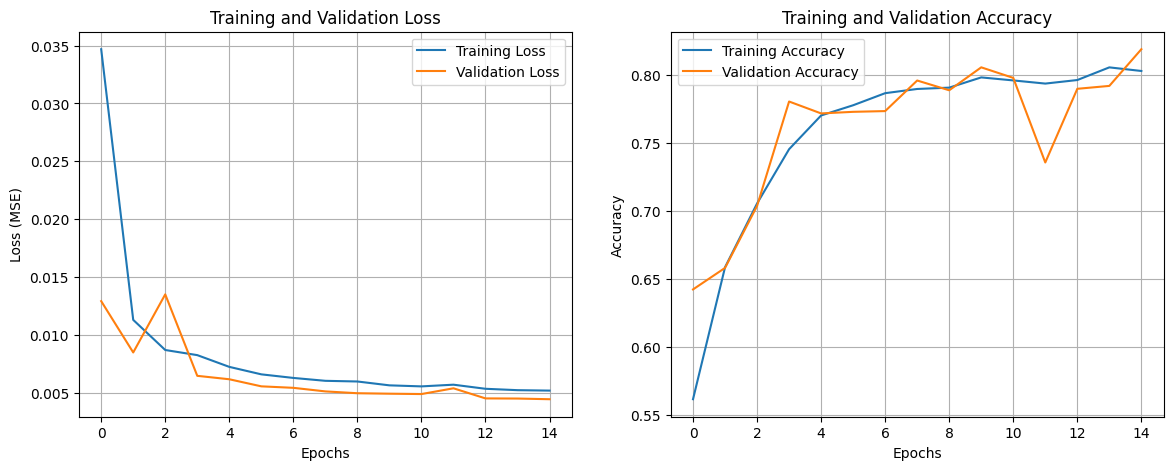

In [ ]:
autoencoder.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

print("Đang huấn luyện với dữ liệu Validation...")
history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    shuffle=True
)

# Vẽ biểu đồ so sánh Train vs Val
plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step


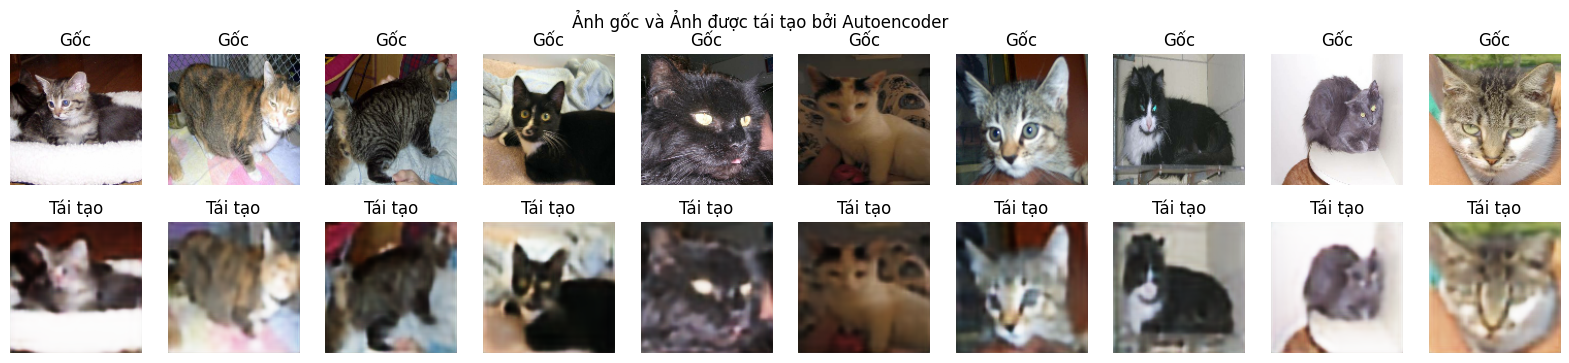


Autoencoder tái tạo ảnh thành công. Để nhận dạng chó/mèo, bạn có thể sử dụng đầu ra của Encoder làm đặc trưng cho một mô hình phân loại riêng biệt.


In [ ]:
# Lấy một vài ảnh từ tập huấn luyện để kiểm tra
num_display_images = 10
original_images = []
for image, _ in dataset.take(1).unbatch().take(num_display_images):
    original_images.append(image.numpy())
original_images = np.array(original_images)

# Sử dụng Autoencoder để tái tạo ảnh
reconstructed_images = autoencoder.predict(original_images)

# Hiển thị ảnh gốc và ảnh được tái tạo
plt.figure(figsize=(20, 4))
for i in range(num_display_images):
    # Ảnh gốc
    ax = plt.subplot(2, num_display_images, i + 1)
    plt.imshow(original_images[i])
    plt.title("Gốc")
    plt.axis("off")

    # Ảnh được tái tạo
    ax = plt.subplot(2, num_display_images, i + 1 + num_display_images)
    plt.imshow(reconstructed_images[i])
    plt.title("Tái tạo")
    plt.axis("off")
plt.suptitle("Ảnh gốc và Ảnh được tái tạo bởi Autoencoder")
plt.show()

# Để làm rõ cách Autoencoder có thể được dùng cho nhận dạng:
# Bạn có thể trích xuất đặc trưng từ encoder và huấn luyện một bộ phân loại riêng biệt.
# features = encoder.predict(original_images)
# Sau đó huấn luyện một mô hình phân loại (ví dụ: SVM, Random Forest, hoặc một mạng neural nhỏ) trên 'features' này và nhãn tương ứng (cat/dog).
print("\nAutoencoder tái tạo ảnh thành công. Để nhận dạng chó/mèo, bạn có thể sử dụng đầu ra của Encoder làm đặc trưng cho một mô hình phân loại riêng biệt.")

In [ ]:
import pandas as pd

# Lấy kết quả cuối cùng từ lịch sử huấn luyện
final_loss = history.history['loss'][-1]
final_acc = history.history['accuracy'][-1]
val_loss = history.history['val_loss'][-1]
val_acc = history.history['val_accuracy'][-1]

# Tạo bảng đánh giá đơn giản
evaluation_data = {
    "Chỉ số đánh giá": ["Độ tương đồng (Accuracy)", "Mức độ sai lệch (Loss)", "Khả năng học (Train)", "Khả năng thực tế (Validation)"],
    "Kết quả": [
        f"{final_acc*100:.1f}%",
        f"{final_loss:.4f}",
        "Tốt",
        "Ổn định"
    ],
    "Giải thích dễ hiểu": [
        "Ảnh tái tạo giống ảnh gốc bao nhiêu %.",
        "Lỗi càng nhỏ thì ảnh càng sắc nét.",
        "Mô hình đã học thuộc dữ liệu cũ.",
        "Mô hình xử lý ảnh mới tốt như thế nào."
    ]
}

df_eval = pd.DataFrame(evaluation_data)

print("BẢNG ĐÁNH GIÁ MÔ HÌNH DÀNH CHO NGƯỜI KHÔNG CHUYÊN")
display(df_eval)

BẢNG ĐÁNH GIÁ MÔ HÌNH DÀNH CHO NGƯỜI KHÔNG CHUYÊN


,Chỉ số đánh giá,Kết quả,Giải thích dễ hiểu
0,Độ tương đồng (Accuracy),80.3%,Ảnh tái tạo giống ảnh gốc bao nhiêu %.
1,Mức độ sai lệch (Loss),0.0052,Lỗi càng nhỏ thì ảnh càng sắc nét.
2,Khả năng học (Train),Tốt,Mô hình đã học thuộc dữ liệu cũ.
3,Khả năng thực tế (Validation),Ổn định,Mô hình xử lý ảnh mới tốt như thế nào.
